# Indonesia vs World — Job Family Exposure Gap

Compares AI task penetration in Indonesia against:
- The global baseline (`task_penetration` from the paper)
- Other countries in the same AEI release

Aggregated to O*NET Job Family level.

## Step 1 — Build global Job Family exposure baseline

From `master` (occupation level), average `observed_exposure` by `JobFamily`.

In [2]:
from huggingface_hub import hf_hub_download
import pandas as pd
import numpy as np

REPO      = 'Anthropic/EconomicIndex'
REPO_TYPE = 'dataset'

def load(path):
    local = hf_hub_download(repo_id=REPO, filename=path, repo_type=REPO_TYPE)
    return pd.read_csv(local)

# Core tables
job_exposure     = load('labor_market_impacts/job_exposure.csv')
task_penetration = load('labor_market_impacts/task_penetration.csv')
wages            = load('release_2025_02_10/wage_data.csv')
soc              = load('release_2025_02_10/SOC_Structure.csv')
onet_tasks       = load('release_2025_02_10/onet_task_statements.csv')

# Rebuild master
wages['occ_code'] = wages['SOCcode'].str[:7]
wages_deduped = (wages.sort_values('JobForecast', ascending=False)
                 .drop_duplicates(subset='occ_code', keep='first'))

master = job_exposure.merge(
    wages_deduped[['occ_code','JobFamily','JobZone','MedianSalary',
                   'JobForecast','ChanceAuto','isBright','WageGroup']],
    on='occ_code', how='left'
)
master['major_group_code'] = master['occ_code'].str[:2] + '-0000'
major_groups = (soc[soc['Major Group'].notna()]
                [['Major Group','SOC or O*NET-SOC 2019 Title']]
                .rename(columns={'Major Group':'major_group_code',
                                 'SOC or O*NET-SOC 2019 Title':'major_group_title'}))
master = master.merge(major_groups, on='major_group_code', how='left')

# Rebuild gap_df
aei_mar26_ai = load('release_2026_03_24/data/aei_raw_claude_ai_2026-02-05_to_2026-02-12.csv')
GEO_DF  = aei_mar26_ai[aei_mar26_ai['geography'] == 'country'].copy()
GEO_COL = 'geo_id'

onet_geo = GEO_DF[
    (GEO_DF['facet'] == 'onet_task') &
    (GEO_DF['variable'] == 'onet_task_pct')
][['geo_id','cluster_name','value']].rename(columns={
    'cluster_name':'task', 'value':'country_pct'
})

global_pen = task_penetration.copy()
global_pen['task'] = global_pen['task'].str.lower().str.strip()
onet_geo['task']   = onet_geo['task'].str.lower().str.strip()

gap_df = onet_geo.merge(global_pen, on='task', how='left')
gap_df['adoption_gap'] = gap_df['penetration'] - gap_df['country_pct']

indo_gap = (gap_df[gap_df['geo_id'] == 'ID']
            .sort_values('adoption_gap', ascending=False)
            .dropna(subset=['penetration']))

print('master:', master.shape)
print('gap_df:', gap_df.shape)
print('indo_gap:', indo_gap.shape)
print('All variables ready.')

master: (756, 12)
gap_df: (7597, 5)
indo_gap: (103, 5)
All variables ready.


In [3]:
# Global baseline: mean observed_exposure per JobFamily
global_family = (
    master
    .dropna(subset=['JobFamily', 'observed_exposure'])
    .groupby('JobFamily')
    .agg(
        global_exposure = ('observed_exposure', 'mean'),
        n_occupations   = ('occ_code', 'count')
    )
    .reset_index()
    .sort_values('global_exposure', ascending=False)
)

print('Global Job Family exposure baseline:')
display(global_family)

Global Job Family exposure baseline:


,JobFamily,global_exposure,n_occupations
5,Computer and Mathematical,0.319360,5
20,Sales and Related,0.236095,20
13,Legal,0.215757,7
16,Office and Administrative Support,0.190566,50
3,Business and Financial Operations,0.173482,28
1,"Arts, Design, Entertainment, Sports, and Media",0.134038,32
14,"Life, Physical, and Social Science",0.132351,37
7,"Education, Training, and Library",0.123575,52
15,Management,0.096983,30
11,Healthcare Support,0.060777,13


## Step 2 — Compute country-level exposure per Job Family

From `gap_df` (country × task penetration), join O*NET task → occupation → JobFamily,
then average by country and JobFamily.

In [4]:
# Join gap_df tasks to onet_tasks to get occ_code
onet_tasks['task_clean'] = onet_tasks['Task'].str.lower().str.strip()
gap_df['task_clean']     = gap_df['task'].str.lower().str.strip()

gap_with_occ = gap_df.merge(
    onet_tasks[['task_clean', 'O*NET-SOC Code']].drop_duplicates(),
    on='task_clean', how='left'
)
gap_with_occ['occ_code'] = gap_with_occ['O*NET-SOC Code'].str[:7]

# Join to master to get JobFamily
gap_with_family = gap_with_occ.merge(
    master[['occ_code', 'JobFamily']].drop_duplicates(),
    on='occ_code', how='left'
)

print('gap_with_family shape:', gap_with_family.shape)
print('JobFamily matched:', gap_with_family['JobFamily'].notna().sum(), '/', len(gap_with_family))
display(gap_with_family.head(3))

gap_with_family shape: (11125, 9)
JobFamily matched: 7972 / 11125


,geo_id,task,country_pct,penetration,adoption_gap,task_clean,O*NET-SOC Code,occ_code,JobFamily
0,AE,"advise clients on market conditions, prices, m...",0.425170,NaN,NaN,"advise clients on market conditions, prices, m...",41-9022.00,41-9022,Sales and Related
1,AE,analyze information obtained from management t...,0.318878,0.8842,0.565322,analyze information obtained from management t...,15-2031.00,15-2031,Computer and Mathematical
2,AE,analyze operations to evaluate performance of ...,0.531463,0.8310,0.299537,analyze operations to evaluate performance of ...,11-1011.00,11-1011,Management


In [5]:
# Country × JobFamily mean penetration
country_family = (
    gap_with_family
    .dropna(subset=['JobFamily', 'geo_id'])
    .groupby(['geo_id', 'JobFamily'])
    .agg(
        country_penetration = ('country_pct', 'mean'),
        n_tasks             = ('task', 'count')
    )
    .reset_index()
)

print('country_family shape:', country_family.shape)
display(country_family[country_family['geo_id'] == 'ID'])

country_family shape: (661, 4)


,geo_id,JobFamily,country_penetration,n_tasks
273,ID,Architecture and Engineering,0.141822,1
274,ID,"Arts, Design, Entertainment, Sports, and Media",0.429707,13
275,ID,Community and Social Service,0.409707,4
276,ID,"Education, Training, and Library",0.304346,239
277,ID,"Farming, Fishing, and Forestry",0.212732,1
278,ID,Food Preparation and Serving Related,0.149701,1
279,ID,Healthcare Practitioners and Technical,0.141822,2
280,ID,"Installation, Maintenance, and Repair",0.141822,1
281,ID,"Life, Physical, and Social Science",0.209778,8
282,ID,Management,0.146549,5


## Step 3 — Compute the gap: Global exposure vs Country penetration

In [6]:
# Merge global baseline onto country-family table
country_family_gap = country_family.merge(
    global_family[['JobFamily', 'global_exposure', 'n_occupations']],
    on='JobFamily', how='left'
)

# Gap = global observed exposure − country actual penetration
# Positive = country lags behind global AI adoption in this family
country_family_gap['gap'] = (
    country_family_gap['global_exposure'] - 
    country_family_gap['country_penetration']
)

print('country_family_gap shape:', country_family_gap.shape)
display(country_family_gap.head(3))

country_family_gap shape: (661, 7)


,geo_id,JobFamily,country_penetration,n_tasks,global_exposure,n_occupations,gap
0,AE,"Arts, Design, Entertainment, Sports, and Media",0.734599,9,0.134038,32,-0.600562
1,AE,Business and Financial Operations,0.340136,1,0.173482,28,-0.166654
2,AE,Community and Social Service,1.721939,1,0.051617,12,-1.670322


## Step 4 — Indonesia vs World

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Indonesia gap
indo_family_gap = (
    country_family_gap[country_family_gap['geo_id'] == 'ID']
    .sort_values('gap', ascending=False)
    .reset_index(drop=True)
)

# World median gap per Job Family (all countries)
world_median_gap = (
    country_family_gap
    .groupby('JobFamily')['gap']
    .median()
    .reset_index()
    .rename(columns={'gap': 'world_median_gap'})
)

# Merge
comparison = indo_family_gap.merge(world_median_gap, on='JobFamily', how='left')

print('Indonesia vs World median gap by Job Family:')
display(comparison[['JobFamily', 'global_exposure', 'country_penetration',
                     'gap', 'world_median_gap', 'n_tasks']]
        .sort_values('gap', ascending=False)
        .to_string(index=False))

Indonesia vs World median gap by Job Family:


'                                     JobFamily  global_exposure  country_penetration       gap  world_median_gap  n_tasks\n                             Sales and Related         0.236095             0.244248 -0.008153         -0.311750        3\n                                    Management         0.096983             0.146549 -0.049566         -0.210216        5\n            Life, Physical, and Social Science         0.132351             0.209778 -0.077426         -0.144133        8\n                  Architecture and Engineering         0.038071             0.141822 -0.103751         -0.189980        1\n        Healthcare Practitioners and Technical         0.026412             0.141822 -0.115410         -0.125222        2\n         Installation, Maintenance, and Repair         0.007120             0.141822 -0.134702         -0.175015        1\n          Food Preparation and Serving Related         0.010100             0.149701 -0.139601         -0.168928        1\n               

## Step 5 — Visualize

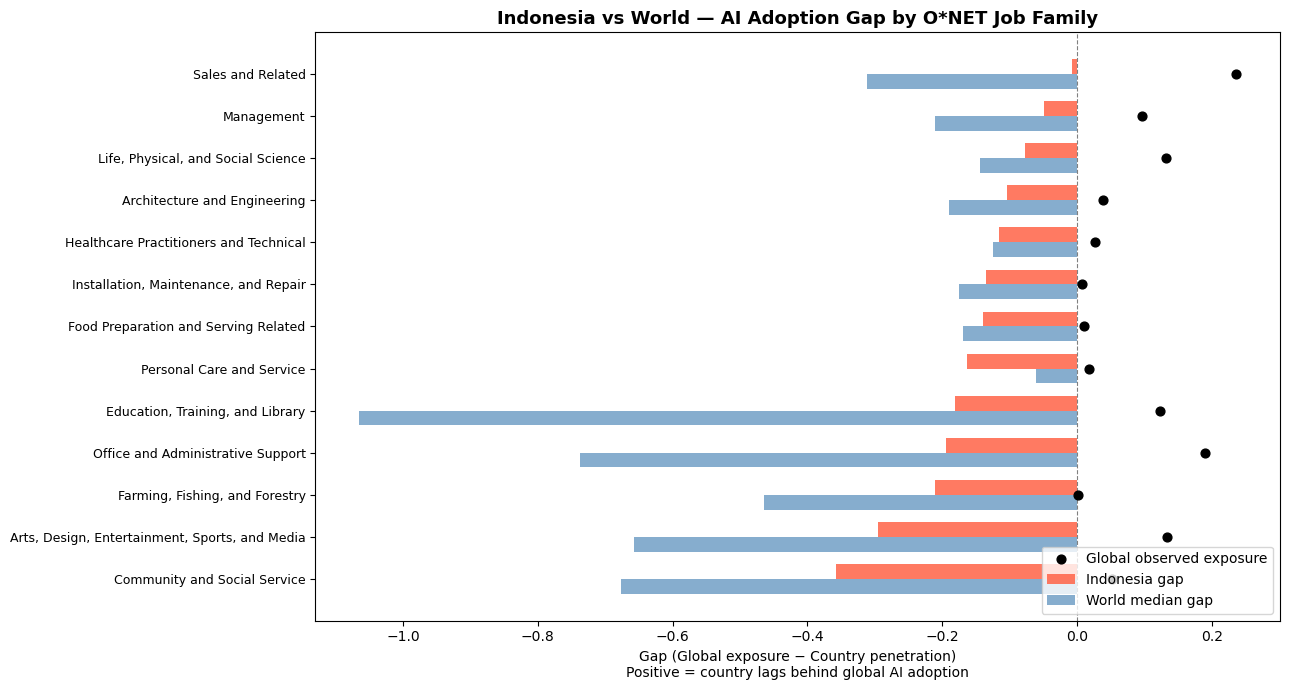

Figure saved.


In [8]:
# Sort by Indonesia gap
plot_df = comparison.sort_values('gap', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 7))

y = np.arange(len(plot_df))
bar_width = 0.35

# Indonesia gap bars
bars_indo = ax.barh(
    y + bar_width / 2, plot_df['gap'],
    height=bar_width, color='tomato', alpha=0.85, label='Indonesia gap'
)

# World median gap bars
bars_world = ax.barh(
    y - bar_width / 2, plot_df['world_median_gap'],
    height=bar_width, color='steelblue', alpha=0.65, label='World median gap'
)

# Global exposure dots
ax.scatter(
    plot_df['global_exposure'], y,
    color='black', zorder=5, s=40, label='Global observed exposure'
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df['JobFamily'], fontsize=9)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Gap (Global exposure − Country penetration)\nPositive = country lags behind global AI adoption')
ax.set_title('Indonesia vs World — AI Adoption Gap by O*NET Job Family', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('processed/indonesia_vs_world_job_family_gap.png', dpi=150)
plt.show()
print('Figure saved.')

In [9]:
# Extra: how does Indonesia rank vs other countries per Job Family?
# Rank 1 = largest gap (most lagging)
country_family_gap['rank'] = (
    country_family_gap
    .groupby('JobFamily')['gap']
    .rank(ascending=False)
)

n_countries = country_family_gap['geo_id'].nunique()

indo_rank = (
    country_family_gap[country_family_gap['geo_id'] == 'ID']
    [['JobFamily', 'gap', 'rank']]
    .sort_values('rank')
    .reset_index(drop=True)
)
indo_rank['rank_of'] = f'{n_countries} countries'

print(f'Indonesia rank (1 = most lagging) among {n_countries} countries, by Job Family:')
display(indo_rank)

Indonesia rank (1 = most lagging) among 96 countries, by Job Family:


,JobFamily,gap,rank,rank_of
0,"Farming, Fishing, and Forestry",-0.210887,1.0,96 countries
1,Food Preparation and Serving Related,-0.139601,5.0,96 countries
2,"Installation, Maintenance, and Repair",-0.134702,6.0,96 countries
3,Management,-0.049566,6.0,96 countries
4,Architecture and Engineering,-0.103751,9.0,96 countries
5,"Arts, Design, Entertainment, Sports, and Media",-0.295670,10.0,96 countries
6,Healthcare Practitioners and Technical,-0.115410,11.0,96 countries
7,Office and Administrative Support,-0.193928,11.0,96 countries
8,Sales and Related,-0.008153,11.0,96 countries
9,Personal Care and Service,-0.163217,12.0,96 countries


In [11]:
top10_indo = (
    family_gap_all[family_gap_all['geo_id'] == 'ID']
    .sort_values('mean_country_penetration', ascending=False)
    .head(10)
    .reset_index(drop=True)
)[['JobFamily', 'mean_country_penetration', 'mean_global_penetration', 'n_tasks']]

print('Top 10 Job Families by AI Usage in Indonesia:')
display(top10_indo)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top10_indo['JobFamily'][::-1],
    top10_indo['mean_country_penetration'][::-1],
    color='steelblue', alpha=0.85, label='Indonesia'
)
ax.barh(
    top10_indo['JobFamily'][::-1],
    top10_indo['mean_global_penetration'][::-1],
    color='lightgray', alpha=0.6, label='Global baseline', zorder=0
)
ax.set_xlabel('Mean Task Penetration (share of Claude usage)')
ax.set_title('Top 10 Job Families by AI Usage in Indonesia\nvs Global Baseline', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('processed/top10_indonesia_ai_usage.png', dpi=150)
plt.show()

NameError: name 'family_gap_all' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

y = np.arange(len(top10_indo))
w = 0.35

# Global baseline bars (behind)
ax.barh(y - w/2, top10_indo['mean_global_penetration'],
        height=w, color='lightsteelblue', alpha=0.9, label='Global baseline')

# Indonesia bars (front)
ax.barh(y + w/2, top10_indo['mean_country_penetration'],
        height=w, color='tomato', alpha=0.9, label='Indonesia')

# Add value labels on bars
for i, row in top10_indo.iterrows():
    ax.text(row['mean_country_penetration'] + 0.002, i + w/2,
            f"{row['mean_country_penetration']:.3f}", va='center', fontsize=8, color='tomato')
    ax.text(row['mean_global_penetration'] + 0.002, i - w/2,
            f"{row['mean_global_penetration']:.3f}", va='center', fontsize=8, color='steelblue')

ax.set_yticks(y)
ax.set_yticklabels(top10_indo['JobFamily'], fontsize=10)
ax.set_xlabel('Mean Task Penetration\n(share of Claude usage attributed to tasks in this Job Family)', fontsize=9)
ax.set_title('Top 10 Job Families by AI Usage in Indonesia\nvs Global Baseline',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, top10_indo['mean_global_penetration'].max() * 1.25)

# Annotation
ax.text(0.98, 0.02,
        'Source: Anthropic Economic Index (Mar 2026)\nMassenkoff & McCrory (2026)',
        transform=ax.transAxes, fontsize=7, ha='right', color='gray')

plt.tight_layout()
plt.savefig('processed/top10_indonesia_ai_usage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: processed/top10_indonesia_ai_usage.png')

In [10]:
# Save
comparison.to_csv('processed/indonesia_vs_world_family_gap.csv', index=False)
indo_rank.to_csv('processed/indonesia_family_rank.csv', index=False)
print('Saved.')

Saved.
